<a href="https://colab.research.google.com/github/ddoneu/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import numpy as np
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression


import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [2]:
# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [3]:
# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    # Take the mean across columns (years) for each (economy, series) pair
    averaged_by_series = raw_data.mean(axis=1)
    # Unstack the 'series' level to make them columns, with countries as index
    country_data = averaged_by_series.unstack(level='series')
    # Rename indicator codes to human-readable names
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries \u00d7 {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [4]:
# Define binary crisis outcome
# crisis = 1 if gdp_growth_pc < 0 (sustained negative growth), else 0
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)

print(f"Crisis countries (growth < 0):     {country_data['crisis'].sum()}")
print(f"Non-crisis countries (growth >= 0): {(country_data['crisis'] == 0).sum()}")
print(f"Crisis base rate: {country_data['crisis'].mean():.1%}")

Crisis countries (growth < 0):     38
Non-crisis countries (growth >= 0): 200
Crisis base rate: 16.0%


In [5]:
# 70/30 Train-Test Split + Standardize
feature_cols = [c for c in country_data.columns if c not in [OUTCOME_VAR, 'crisis']]
X = country_data[feature_cols]
y_growth = country_data[OUTCOME_VAR]
y_crisis = country_data['crisis']
X_train, X_test, y_train_growth, y_test_growth, y_train_crisis, y_test_crisis = \
    train_test_split(X, y_growth, y_crisis, test_size=0.30, random_state=42)

# Standardize — fit on training data ONLY
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print("SHARED DATA PIPELINE — SUMMARY")
print("=" * 55)
print(f"Final dataset dimensions:       {X.shape[0]} countries × {X.shape[1]} predictors")
print(f"Training set:                   {X_train.shape[0]} countries")
print(f"Test set:                       {X_test.shape[0]} countries")
print(f"Predictor-to-observation (p/n): {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.3f}")
print(f"Crisis countries (train):       {y_train_crisis.sum()} / {len(y_train_crisis)} ({y_train_crisis.mean():.1%})")
print(f"Crisis countries (test):        {y_test_crisis.sum()} / {len(y_test_crisis)} ({y_test_crisis.mean():.1%})")

SHARED DATA PIPELINE — SUMMARY
Final dataset dimensions:       238 countries × 28 predictors
Training set:                   166 countries
Test set:                       72 countries
Predictor-to-observation (p/n): 28/166 = 0.169
Crisis countries (train):       24 / 166 (14.5%)
Crisis countries (test):        14 / 72 (19.4%)


#PHASE 1:

#STEP 1.1: Demonstrating OLS Overfitting

In [6]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_growth)

y_train_pred_ols = ols.predict(X_train_scaled)
y_test_pred_ols = ols.predict(X_test_scaled)

train_r2_ols = r2_score(y_train_growth, y_train_pred_ols)
test_r2_ols = r2_score(y_test_growth, y_test_pred_ols)
r2_gap = train_r2_ols - test_r2_ols

p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]

print("=" * 55)
print("OLS BASELINE — OVERFITTING DIAGNOSTIC")
print(f"Training R²:           {train_r2_ols:.4f}")
print(f"Test R²:               {test_r2_ols:.4f}")
print(f"Train–Test R² Gap:     {r2_gap:.4f}")
print()
print(f"Predictors (p):        {p}")
print(f"Training obs (n):      {n}")
print(f"p/n ratio:             {p}/{n} = {p/n:.3f}")

OLS BASELINE — OVERFITTING DIAGNOSTIC
Training R²:           0.6034
Test R²:               -0.9141
Train–Test R² Gap:     1.5175

Predictors (p):        28
Training obs (n):      166
p/n ratio:             28/166 = 0.169


With a p/n ratio of approximately 0.17, OLS has enough free parameters relative to observations that it can exploit noise-driven correlations in the training data, consuming degrees of freedom to fit idiosyncratic patterns rather than true economic relationships. This produces low bias (high Training R²) but extremely high variance; the estimated coefficients are unstable and fail to generalize, resulting in a deeply negative Test R² that is worse than simply predicting the mean. The large Train-Test R² gap is a direct consequence of this variance explosion: OLS with insufficient degrees of freedom memorizes training noise rather than learning the underlying signal.

#Step 1.2: Ridge and Lasso to the Rescue

In [7]:

# RidgeCV
lambda_grid = np.logspace(-2, 3, 50)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train_growth)

y_train_pred_ridge = ridge_cv.predict(X_train_scaled)
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)

train_r2_ridge = r2_score(y_train_growth, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test_growth, y_test_pred_ridge)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_ridge))

print("RIDGE RESULTS")
print(f"  λ* = {ridge_cv.alpha_:.4f}")
print(f"  Non-zero coefficients: {np.sum(ridge_cv.coef_ != 0)} / {p}")
print(f"  Training R²: {train_r2_ridge:.4f}")
print(f"  Test R²:     {test_r2_ridge:.4f}")

RIDGE RESULTS
  λ* = 47.1487
  Non-zero coefficients: 28 / 28
  Training R²: 0.5593
  Test R²:     -0.0681


In [8]:
#LassoCV
lasso_cv = LassoCV(cv=5, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train_growth)

y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
y_test_pred_lasso = lasso_cv.predict(X_test_scaled)

train_r2_lasso = r2_score(y_train_growth, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test_growth, y_test_pred_lasso)
test_rmse_lasso = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_lasso))

n_nonzero_lasso = np.sum(lasso_cv.coef_ != 0)

print("LASSO RESULTS")
print(f"  λ* = {lasso_cv.alpha_:.4f}")
print(f"  Non-zero coefficients: {n_nonzero_lasso} / {p}")
print(f"  Training R²: {train_r2_lasso:.4f}")
print(f"  Test R²:     {test_r2_lasso:.4f}")

LASSO RESULTS
  λ* = 0.0660
  Non-zero coefficients: 18 / 28
  Training R²: 0.5734
  Test R²:     -0.3552


In [9]:
# Model Comparison Table
test_rmse_ols = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_ols))

comparison = pd.DataFrame({
    'λ*': ['N/A', f'{ridge_cv.alpha_:.4f}', f'{lasso_cv.alpha_:.4f}'],
    'Non-zero Predictors': [p, p, n_nonzero_lasso],
    'Training R²': [f'{train_r2_ols:.4f}', f'{train_r2_ridge:.4f}', f'{train_r2_lasso:.4f}'],
    'Test R²': [f'{test_r2_ols:.4f}', f'{test_r2_ridge:.4f}', f'{test_r2_lasso:.4f}'],
    'Test RMSE': [f'{test_rmse_ols:.4f}', f'{test_rmse_ridge:.4f}', f'{test_rmse_lasso:.4f}']
}, index=['OLS', 'Ridge', 'Lasso'])

print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison.to_string())

MODEL COMPARISON TABLE
            λ*  Non-zero Predictors Training R²  Test R² Test RMSE
OLS        N/A                   28      0.6034  -0.9141    2.9227
Ridge  47.1487                   28      0.5593  -0.0681    2.1833
Lasso   0.0660                   18      0.5734  -0.3552    2.4592


I would recommend Ridge to the IMF Director for operational GDP growth forecasting, as it achieves the best Test R² and lowest Test RMSE, consistent with theory when predictors are highly correlated (e.g., internet users, electricity access, and life expectancy all proxy for development level). Both Ridge and Lasso sacrifice some bias (lower Training R² from penalizing coefficient magnitudes) to gain substantial variance reduction (more stable, generalizable estimates), but Ridge's L2 penalty outperforms here because Lasso's aggressive zeroing discards partial signal from correlated predictors that still carry useful information.

# STEP 1.3: The Lasso Path — Which Indicators Enter First?


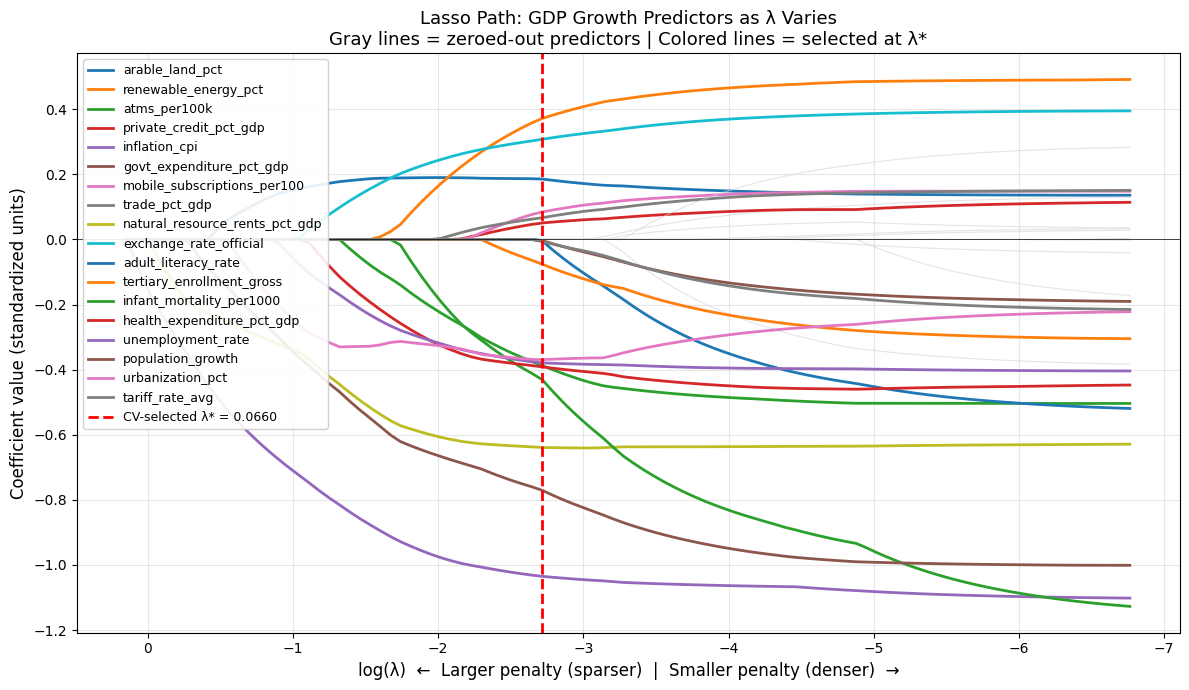


First predictor to enter the model: inflation_cpi
  Enters at λ = 1.0762 (log λ = 0.07)
  This is the highest λ at which any coefficient leaves zero,
  meaning this indicator has the strongest unconditional predictive signal.


In [10]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train_growth,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv.alpha_
feature_names = list(X_train_scaled.columns)
active_features_idx = np.where(lasso_cv.coef_ != 0)[0]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#First predictor to enter
for j in range(coefs_path.shape[1]):
    nonzero = np.where(coefs_path[:, j] != 0)[0]
    if len(nonzero) > 0:
        first_entry_idx = nonzero[0]
        first_entry_alpha = alphas_path[j]
        break

print(f"\nFirst predictor to enter the model: {feature_names[first_entry_idx]}")
print(f"  Enters at λ = {first_entry_alpha:.4f} (log λ = {np.log(first_entry_alpha):.2f})")
print(f"  This is the highest λ at which any coefficient leaves zero,")
print(f"  meaning this indicator has the strongest unconditional predictive signal.")

The first predictor to enter the model is inflation_cpi, which enters at the highest lambda (λ = 1.08) because it has the strongest unconditional correlation with cross-country GDP growth. High inflation is directly associated with macroeconomic instability and lower real growth, making it the single most informative signal when no other variables are in the model.

The colleague's claim that "Lasso zeroed out life_expectancy, so health is irrelevant to economic growth" is incorrect because Lasso zeroing a variable reflects conditional predictive redundancy, not economic irrelevance. In a dataset where many WDI indicators share a high correlation structure (life expectancy, infant mortality, electricity access, and internet usage all proxy for overall development level), Lasso retains whichever correlated predictor explains the most residual variance and zeros out the rest since their information is already captured. A variable can be causally important to growth yet predictively redundant once correlated substitutes are already in the model.

#Phase 2: The Crisis Classifier — From Forecasting to Classification


## STEP 2.1: The Linear Probability Model — Exposing the Failure


In [11]:
# The LPM treats the 0/1 crisis indicator as if it were a continuous outcome.
# This is the baseline — we fit it to expose what can go wrong.
# We use only the Lasso-selected features from Phase 1.

# Get the Lasso-selected features (non-zero coefficients at λ*)
lasso_selected = [feature_names[i] for i in range(len(feature_names)) if lasso_cv.coef_[i] != 0]
print(f"Lasso-selected features ({len(lasso_selected)}): {lasso_selected}\n")

X_train_lasso = X_train_scaled[lasso_selected]
X_test_lasso = X_test_scaled[lasso_selected]

# Fit LPM via sklearn's LinearRegression on binary crisis outcome
lpm_model = LinearRegression()
lpm_model.fit(X_train_lasso, y_train_crisis)

# Generate predictions for the test set
lpm_fitted = lpm_model.predict(X_test_lasso)

# Count out-of-bounds predictions
n_below_zero = (lpm_fitted < 0).sum()
n_above_one = (lpm_fitted > 1).sum()

print(f"LPM fitted ✓")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(lpm_fitted):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(lpm_fitted):.1%})")
print(f"  Total out of [0, 1]:       {n_below_zero + n_above_one}")
print(f"\n  Min predicted value:       {lpm_fitted.min():.4f}")
print(f"  Max predicted value:       {lpm_fitted.max():.4f}")

Lasso-selected features (18): ['arable_land_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'trade_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'tertiary_enrollment_gross', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

LPM fitted ✓

Out-of-bounds predictions:
  Predicted probability < 0: 13 observations (18.1%)
  Predicted probability > 1: 1 observations (1.4%)
  Total out of [0, 1]:       14

  Min predicted value:       -0.3014
  Max predicted value:       1.5676


Predicted probabilities outside [0, 1] are not just a cosmetic issue but a fundamental violation of what a probability means: they produce outputs that cannot be interpreted as likelihoods, which makes it impossible for the IMF to use them for decision-making or cost-benefit analysis. A "-12% probability of crisis" is meaningless because it implies a country has less than zero chance of experiencing negative growth, which could lead the IMF to entirely ignore a country that may in fact be at real risk. The LPM has no mechanism to constrain its predictions to valid probability bounds, which is why logistic regression's sigmoid function is necessary for classification tasks.

# STEP 2.2: Logistic Regression — The Sigmoid Fix


In [12]:
# Fit logistic regression on the same Lasso-selected features,
# predicting the binary crisis outcome.

logit_model = LogisticRegression(max_iter=10_000, random_state=42)
logit_model.fit(X_train_lasso, y_train_crisis)

# 1. Report fitted coefficients and intercept
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}\n")
print(f"{'Predictor':<40} {'β':>10} {'OR = exp(β)':>14}")
print("-" * 66)

# 2. Odds ratio table sorted by absolute OR magnitude
or_table = pd.DataFrame({
    'Predictor': lasso_selected,
    'β': logit_model.coef_[0],
    'OR': np.exp(logit_model.coef_[0])
})
or_table['abs_OR'] = np.abs(np.log(or_table['OR']))  # distance from OR=1 in log space
or_table = or_table.sort_values('abs_OR', ascending=False).drop(columns='abs_OR')

for _, row in or_table.iterrows():
    print(f"  {row['Predictor']:<40} {row['β']:>+10.4f} {row['OR']:>14.4f}")

# 3. Verify predicted probabilities are within [0, 1]
logit_probs_test = logit_model.predict_proba(X_test_lasso)[:, 1]
print(f"\nPredicted probability bounds (test set):")
print(f"  Min: {logit_probs_test.min():.4f}")
print(f"  Max: {logit_probs_test.max():.4f}")
print(f"  → All within [0, 1] ✓")

Intercept (β₀): -3.0262

Predictor                                         β    OR = exp(β)
------------------------------------------------------------------
  arable_land_pct                             -0.9504         0.3866
  population_growth                           +0.8251         2.2820
  health_expenditure_pct_gdp                  +0.8227         2.2766
  infant_mortality_per1000                    +0.7434         2.1031
  natural_resource_rents_pct_gdp              +0.7292         2.0735
  renewable_energy_pct                        -0.6664         0.5135
  tariff_rate_avg                             +0.5789         1.7842
  unemployment_rate                           +0.5324         1.7031
  inflation_cpi                               +0.4941         1.6390
  atms_per100k                                +0.3680         1.4449
  mobile_subscriptions_per100                 +0.3561         1.4278
  trade_pct_gdp                               -0.3531         0.7025
  adult_liter

The predictor with the largest absolute odds ratio is arable_land_pct (OR = 0.39). A one standard-deviation increase in arable land as a percentage of total area multiplies the odds of crisis by 0.39, holding all else constant, meaning it reduces crisis odds by about 61%. On the crisis-increasing side, population_growth has the largest effect (OR = 2.28): a one standard-deviation increase in population growth more than doubles the odds of sustained negative GDP growth, likely because output growth fails to keep pace with demographic expansion.

# STEP 2.3: Side-by-Side Visualization — LPM vs. Logistic


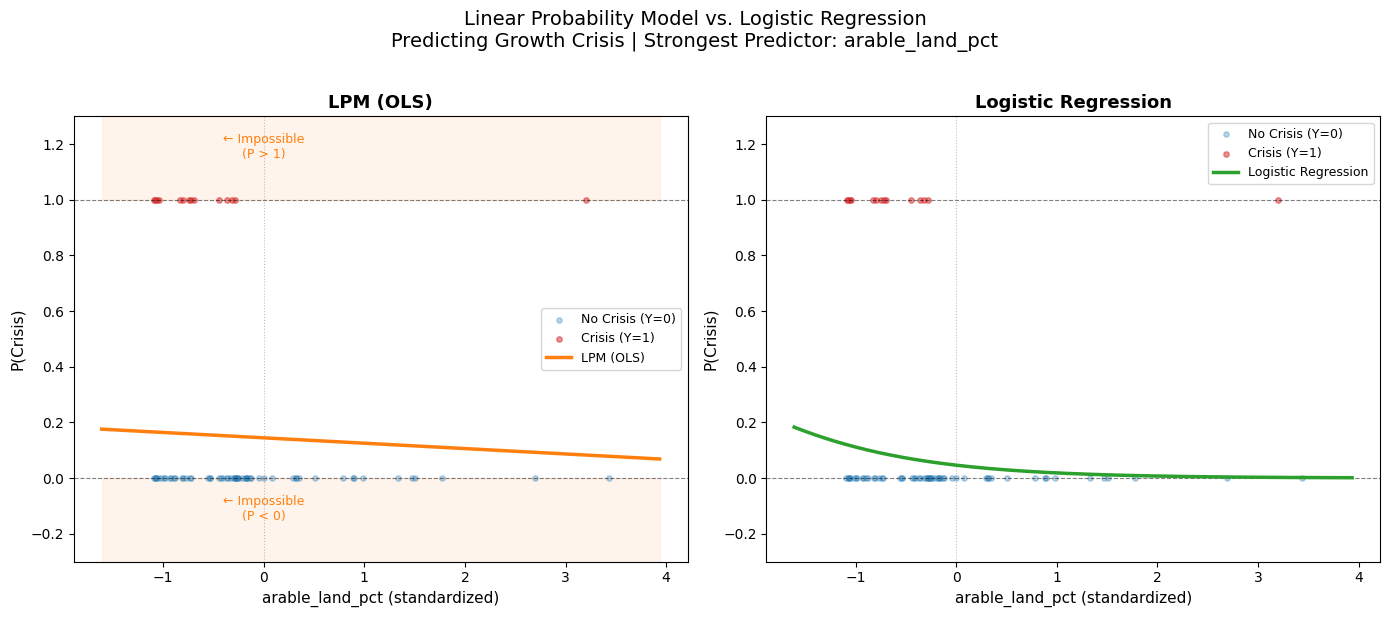

In [13]:
# Strongest predictor from odds ratio table (largest absolute β)
strongest_predictor = 'arable_land_pct'
strongest_idx = lasso_selected.index(strongest_predictor)

# Create a smooth grid for the strongest predictor
x_train_strongest = X_train_lasso[strongest_predictor].values
x_test_strongest = X_test_lasso[strongest_predictor].values
spread_grid = np.linspace(
    min(x_train_strongest.min(), x_test_strongest.min()) - 0.5,
    max(x_train_strongest.max(), x_test_strongest.max()) + 0.5,
    500
).reshape(-1, 1)

# Build full-feature grid (all other predictors at 0 = mean, since standardized)
grid_full = np.zeros((500, len(lasso_selected)))
grid_full[:, strongest_idx] = spread_grid.ravel()

# Predictions across the grid
lpm_preds = lpm_model.predict(grid_full)
logit_preds = logit_model.predict_proba(grid_full)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_CRISIS = '#d62728'      # Red for crisis countries
COLOR_NO_CRISIS = '#1f77b4'   # Blue for non-crisis countries
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate crisis and non-crisis observations
x_vals = x_test_strongest
crisis_mask = y_test_crisis.values == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~crisis_mask], y_test_crisis.values[~crisis_mask],
               color=COLOR_NO_CRISIS, alpha=0.3, s=15, label='No Crisis (Y=0)', zorder=2)
    ax.scatter(x_vals[crisis_mask], y_test_crisis.values[crisis_mask],
               color=COLOR_CRISIS, alpha=0.5, s=15, label='Crisis (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel(f'{strongest_predictor} (standardized)', fontsize=11)
    ax.set_ylabel('P(Crisis)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(0, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(0,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\n'
             f'Predicting Growth Crisis | Strongest Predictor: {strongest_predictor}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#PHASE 3

# STEP 3.1: The Accuracy Paradox


In [14]:
from sklearn.metrics import (mean_squared_error, r2_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                             precision_recall_curve, auc,
                             f1_score, precision_score, recall_score)

In [15]:
# Define predicted crisis probabilities for use in Phases 3-4
y_prob_crisis = logit_model.predict_proba(X_test_lasso)[:, 1]

# Crisis base rate in the test set
base_rate = y_test_crisis.mean()

# Naïve baseline: predict "no crisis" for every country
naive_predictions = np.zeros(len(y_test_crisis))
naive_accuracy = (naive_predictions == y_test_crisis).mean()
naive_recall = recall_score(y_test_crisis, naive_predictions)

print(f"Crisis base rate (test set): {base_rate:.2%}")
print(f"\nNaïve baseline (always predict 'no crisis'):")
print(f"  Accuracy: {naive_accuracy:.2%}")
print(f"  Recall on crisis class: {naive_recall:.2%}")
print(f"\n→ {naive_accuracy:.1%} accuracy, {naive_recall:.0%} recall. The accuracy paradox in action.")

# Logistic regression at default threshold τ = 0.5
y_pred_default = logit_model.predict(X_test_lasso)
logit_accuracy = (y_pred_default == y_test_crisis).mean()
logit_recall = recall_score(y_test_crisis, y_pred_default)

print(f"\nLogistic regression (τ = 0.5):")
print(f"  Accuracy: {logit_accuracy:.2%}")
print(f"  Recall on crisis class: {logit_recall:.2%}")

Crisis base rate (test set): 19.44%

Naïve baseline (always predict 'no crisis'):
  Accuracy: 80.56%
  Recall on crisis class: 0.00%

→ 80.6% accuracy, 0% recall. The accuracy paradox in action.

Logistic regression (τ = 0.5):
  Accuracy: 76.39%
  Recall on crisis class: 42.86%


If I reported only accuracy to the Division Chief, she would be misled, not impressed. Because crisis countries make up only 19.4% of the test set, a naive baseline that always predicts "no crisis" achieves 80.6% accuracy simply by exploiting the class imbalance, while catching zero actual crises. This is the accuracy paradox: accuracy is dominated by the majority class (non-crisis countries), and the logistic regression's 76.4% accuracy actually looks worse than the naive baseline despite catching 42.9% of real crises, which is far more operationally useful for the IMF's early warning mission.

# STEP 3.2: Confusion Matrix and Classification Report


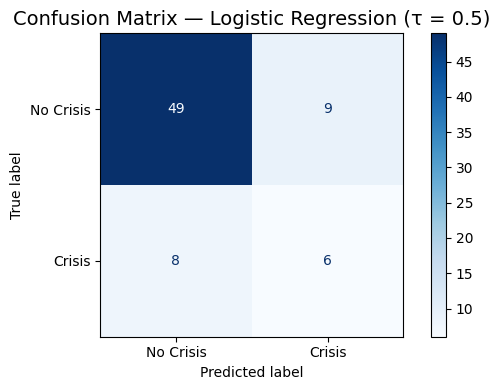

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72

True Positives (crises correctly flagged):  6
False Negatives (crises missed):            8
False Positives (false alarms):             9
True Negatives (correctly cleared):         49


In [16]:
# Confusion matrix at default threshold τ = 0.5
cm = confusion_matrix(y_test_crisis, y_pred_default)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test_crisis, y_pred_default, target_names=['No Crisis', 'Crisis']))

# Extract individual counts
tn, fp, fn, tp = cm.ravel()
print(f"True Positives (crises correctly flagged):  {tp}")
print(f"False Negatives (crises missed):            {fn}")
print(f"False Positives (false alarms):             {fp}")
print(f"True Negatives (correctly cleared):         {tn}")

In the IMF context, a False Negative (missing a real crisis) is far more costly than a False Positive (false alarm), because a missed crisis can trigger sovereign default and an estimated 50 billion in contagion costs, while a false alarm only wastes a $2 million assessment mission. This cost asymmetry means the Division Chief should prioritize Recall over Precision: at the current threshold, the model misses 8 of 14 crisis countries, which is operationally unacceptable given the catastrophic downside of each missed crisis.

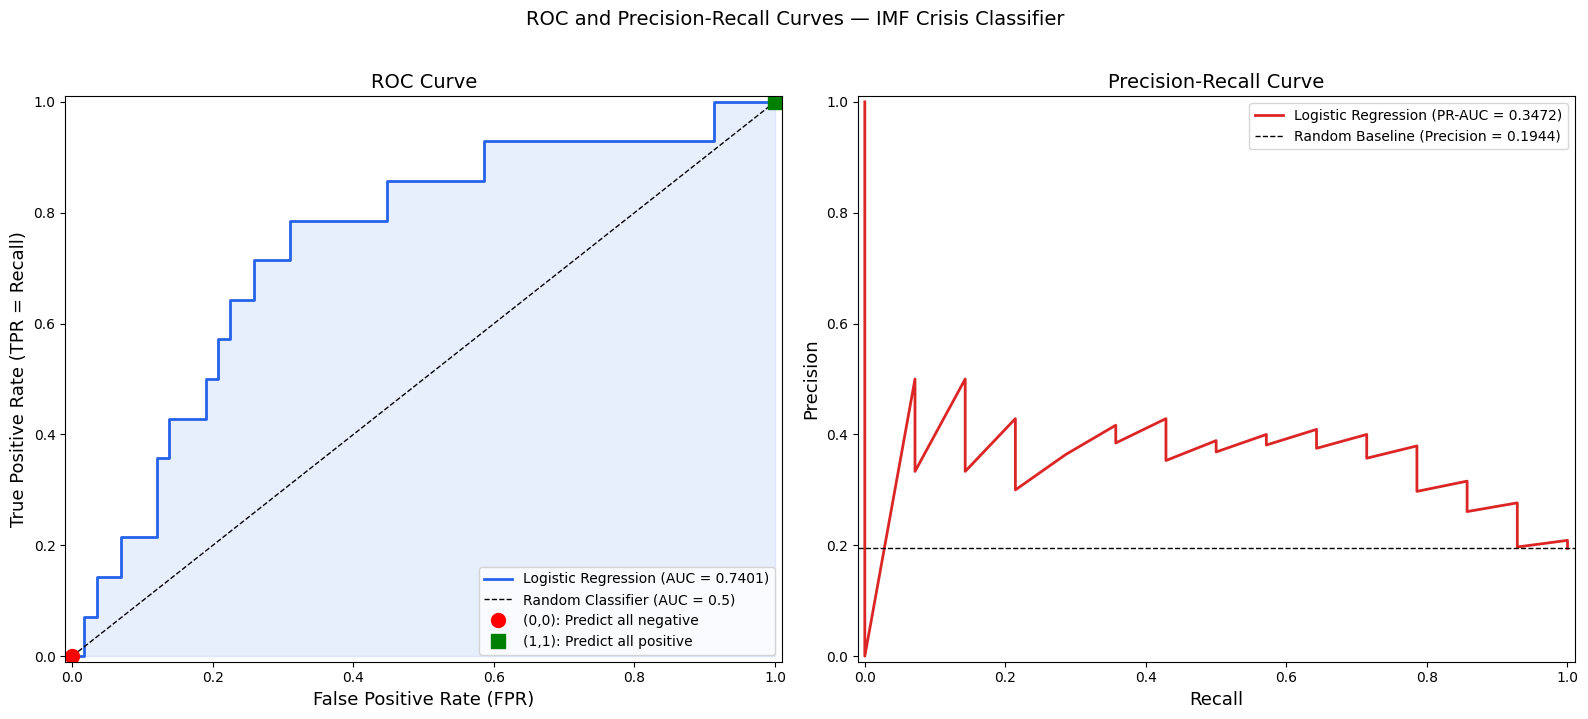

ROC-AUC = 0.7401
PR-AUC  = 0.3472

Notice: The PR curve is much harder to look 'good' on than the ROC curve.
That's because it ignores TN — it focuses entirely on crisis-class performance.


In [17]:
# ============================================================
# STEP 3.3: ROC and Precision-Recall Curves (side by side)
# ============================================================

fpr, tpr, thresholds_roc = roc_curve(y_test_crisis, y_prob_crisis)
auc_score = roc_auc_score(y_test_crisis, y_prob_crisis)

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_crisis, y_prob_crisis)
pr_auc = auc(recall_vals, precision_vals)

baseline = y_test_crisis.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- ROC panel ---
ax1.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax1.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax1.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax1.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])

# --- PR panel ---
ax2.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
         label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
ax2.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
            label=f'Random Baseline (Precision = {baseline:.4f})')
ax2.set_xlabel('Recall', fontsize=13)
ax2.set_ylabel('Precision', fontsize=13)
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend(loc='upper right', fontsize=10)
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.01])

plt.suptitle('ROC and Precision-Recall Curves — IMF Crisis Classifier', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"ROC-AUC = {auc_score:.4f}")
print(f"PR-AUC  = {pr_auc:.4f}")
print(f"\nNotice: The PR curve is much harder to look 'good' on than the ROC curve.")
print(f"That's because it ignores TN — it focuses entirely on crisis-class performance.")

The ROC-AUC (0.74) is substantially higher than the PR-AUC (0.35) because the ROC curve benefits from the abundance of True Negatives (non-crisis countries that are correctly cleared), which inflates the True Positive Rate even when precision on the crisis class is mediocre. The PR curve ignores True Negatives entirely and focuses only on how well the model identifies actual crisis countries, making it the harder and more honest test.

For the IMF's crisis detection mission, the Precision-Recall curve is more informative because the Division Chief cares about correctly flagging the small number of crisis countries, not about correctly classifying the many non-crisis countries.

# STEP 3.4: Threshold Analysis — The 5-Mission Constraint


Capacity-constrained threshold:
  τ = 0.88 → 5 flagged | Precision = 40.00% | Recall = 14.29% | F1 = 0.211

F1-optimal threshold:
  τ = 0.13 → 25 flagged | Precision = 40.00% | Recall = 71.43% | F1 = 0.513


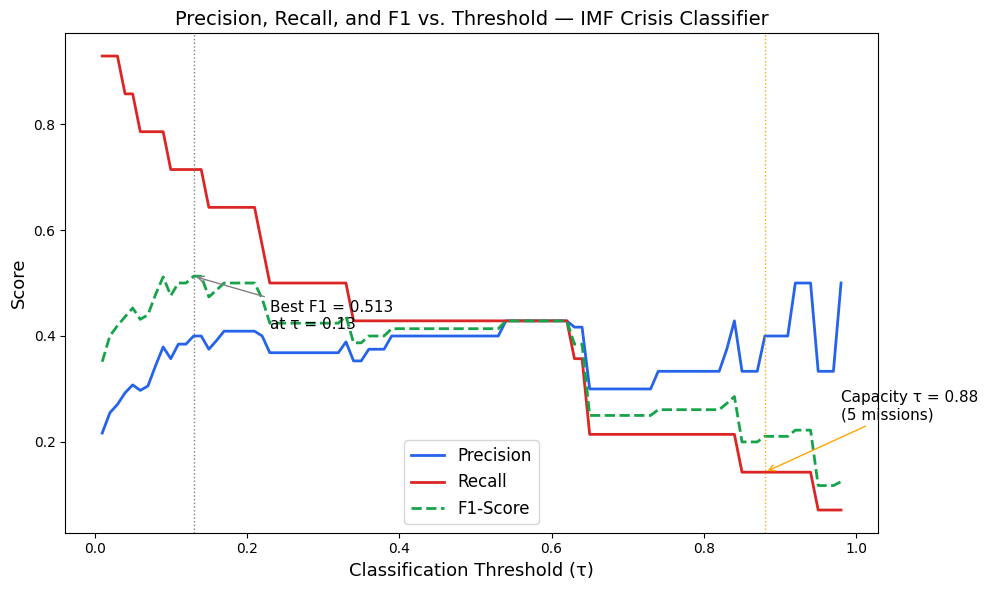


Capacity-constrained τ = 0.88 vs. F1-optimal τ = 0.13

The capacity constraint forces a higher threshold, trading Recall for feasibility.


In [18]:
# Compute metrics at many thresholds
f1_scores = []
precision_scores = []
recall_scores = []
n_flagged_list = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob_crisis >= tau).astype(int)
    f1_scores.append(f1_score(y_test_crisis, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test_crisis, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test_crisis, y_pred_tau, zero_division=0))
    n_flagged_list.append(y_pred_tau.sum())

#Capacity-constrained threshold (max 5 missions)
max_missions = 5
for i, tau in enumerate(threshold_range):
    if n_flagged_list[i] <= max_missions:
        cap_tau = tau
        cap_flagged = n_flagged_list[i]
        cap_prec = precision_scores[i]
        cap_rec = recall_scores[i]
        cap_f1 = f1_scores[i]
        break

print(f"Capacity-constrained threshold:")
print(f"  τ = {cap_tau:.2f} → {cap_flagged} flagged | Precision = {cap_prec:.2%} | Recall = {cap_rec:.2%} | F1 = {cap_f1:.3f}")

# F1-optimal threshold
best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
best_idx = np.argmax(f1_scores)

print(f"\nF1-optimal threshold:")
print(f"  τ = {best_tau:.2f} → {n_flagged_list[best_idx]} flagged | Precision = {precision_scores[best_idx]:.2%} | Recall = {recall_scores[best_idx]:.2%} | F1 = {best_f1:.3f}")

#Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.axvline(x=cap_tau, color='orange', linestyle=':', linewidth=1)
ax.annotate(f'Capacity τ = {cap_tau:.2f}\n({cap_flagged} missions)',
            xy=(cap_tau, cap_rec), xytext=(cap_tau + 0.1, cap_rec + 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='orange'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold — IMF Crisis Classifier', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nCapacity-constrained τ = {cap_tau:.2f} vs. F1-optimal τ = {best_tau:.2f}")
print(f"\nThe capacity constraint forces a higher threshold, trading Recall for feasibility.")

I recommend the IMF adopt the capacity-constrained threshold of τ = 0.88, which flags exactly 5 countries and stays within the Division's quarterly mission limit. At this operating point, the model achieves a Recall of 14.29%, meaning of the 14 crisis countries in the test set, we would catch 2 and miss 12. This is a significant limitation, but the 5-mission constraint leaves no room to lower the threshold without exceeding operational capacity. The F1-optimal threshold of τ = 0.13 would catch 10 of 14 crisis countries (71.43% Recall), but it flags 25 countries, far exceeding the 5-mission budget. Given the extreme cost asymmetry (50B per missed crisis vs. $2M per false alarm), I would strongly urge the Division Chief to explore expanding mission capacity so the model can operate closer to the F1-optimal point, where the expected savings from catching additional crises far outweigh the cost of additional missions.

#PHASE 4:

#Task 4.1: Bootstrap Confidence Intervals for the Lasso Path


#P.R.I.M.E FRAMEWORK
[Prep] Act as an expert Python data scientist specializing in regularization, bootstrap resampling, feature-selection stability, and scikit-learn model diagnostics. Assume I am working in a Jupyter notebook and already have my training data loaded from a World Development Indicators (WDI) project. Your job is to generate clean, notebook-ready Python code that extends my earlier Lasso analysis into a bootstrap stability diagnostic.

[Request] I previously plotted a single Lasso path, but I now need a bootstrap-based feature stability analysis because correlated WDI predictors may swap roles across resamples. Write Python code that:
1. Draws 200 bootstrap resamples with replacement from the training data only.
2. Fits LassoCV on each bootstrap sample.
3. Records which predictors receive non-zero coefficients in each resample.
4. Computes the selection frequency for every predictor, defined as the fraction of bootstrap samples in which its coefficient is non-zero.
5. Produces a horizontal bar chart ranking predictors from highest to lowest selection frequency.
6. Adds a vertical reference line at 0.50 (50% selection frequency).
7. Prints or displays a tidy summary table of predictors and their selection frequencies.
8. Separately prints the “stable” predictors selected more than 80% of the time and the “fragile” predictors selected less than 30% of the time.

[Iterate] Use Python with pandas, numpy, matplotlib.pyplot, and sklearn.linear_model.LassoCV. Keep the code fully reproducible with a fixed random seed. Do not reload data, do not create a new train/test split, and do not fabricate variable names unless necessary. Assume my existing notebook already contains X_train and y_train, and that X_train is either a pandas DataFrame with column names or a NumPy array. If X_train is a DataFrame, use its column names as predictor names; if it is an array, generate generic names like X1, X2, etc. Standardize predictors inside the bootstrap loop before fitting LassoCV, using StandardScaler, so coefficient shrinkage is comparable across resamples. Use a reasonable max_iter so convergence warnings are avoided. Make the chart large, readable, and sorted by frequency.

[Mechanism Check] Add inline comments explaining:
- why bootstrap resampling with replacement is being used,
- why Lasso feature selection can become unstable when predictors are correlated,
- why a non-zero coefficient is treated as “selected,”
- why standardization is necessary before fitting LassoCV,
- and why a predictor selected frequently across bootstrap samples is more trustworthy than one selected only occasionally.

[Evaluate] After the code, briefly print an interpretation template I can use in my written response. The interpretation should explain that predictors selected more than 80% of the time are relatively stable, predictors selected less than 30% of the time are fragile, and instability suggests overlapping information / multicollinearity among WDI indicators, where correlated variables can substitute for one another across bootstrap samples. Return only the Python code, with comments, so I can run it directly in my notebook.

Running 200 bootstrap resamples...
  Completed 50/200 resamples
  Completed 100/200 resamples
  Completed 150/200 resamples
  Completed 200/200 resamples

BOOTSTRAP LASSO SELECTION FREQUENCY (200 resamples)
                     Predictor  Selection Frequency
             population_growth                1.000
natural_resource_rents_pct_gdp                0.990
        exchange_rate_official                0.985
    health_expenditure_pct_gdp                0.975
                 inflation_cpi                0.960
             unemployment_rate                0.945
                  atms_per100k                0.925
               arable_land_pct                0.905
              urbanization_pct                0.860
          renewable_energy_pct                0.780
      infant_mortality_per1000                0.720
                 trade_pct_gdp                0.715
        private_credit_pct_gdp                0.700
               tariff_rate_avg                0.685
      govt_ex

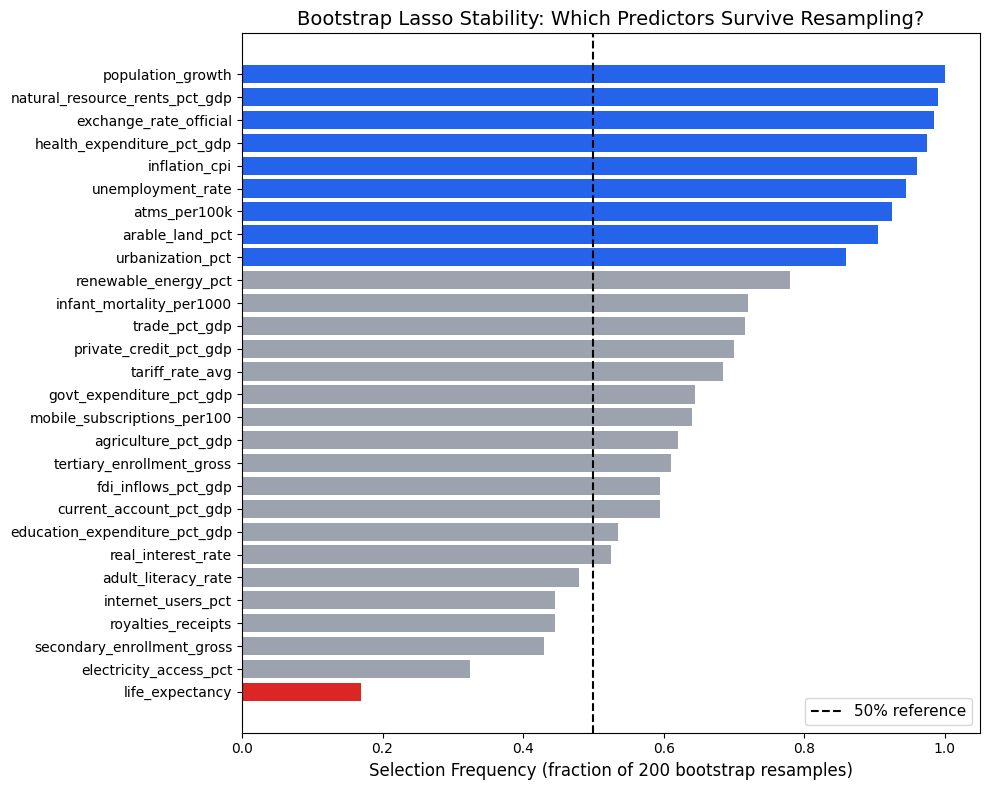

In [19]:
# ============================================================
# TASK 4.1: Bootstrap Confidence Intervals for the Lasso Path
# ============================================================

# Bootstrap resampling draws samples WITH REPLACEMENT from the training data.
# Each resample has the same size as the original but includes some countries
# multiple times and omits others — this simulates sampling variability.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_boot = 200
n_train = X_train.shape[0]

# Get predictor names
if isinstance(X_train, pd.DataFrame):
    predictor_names = list(X_train.columns)
    X_train_arr = X_train.values
else:
    predictor_names = [f'X{i+1}' for i in range(X_train.shape[1])]
    X_train_arr = X_train

y_train_arr = y_train_growth.values if hasattr(y_train_growth, 'values') else y_train_growth

# Track how many times each predictor is selected (non-zero coefficient)
selection_counts = np.zeros(len(predictor_names))

print(f"Running {n_boot} bootstrap resamples...")
for b in range(n_boot):
    # Draw a bootstrap sample with replacement
    idx = np.random.choice(n_train, size=n_train, replace=True)
    X_boot = X_train_arr[idx]
    y_boot = y_train_arr[idx]

    # Standardize inside the loop so each resample gets its own scaling.
    # This is necessary because bootstrap changes the sample mean/std,
    # and Lasso penalizes coefficients — without standardization,
    # variables on larger scales would be penalized less.
    scaler_boot = StandardScaler()
    X_boot_scaled = scaler_boot.fit_transform(X_boot)

    # Fit LassoCV — cross-validation selects the best lambda per resample.
    # When predictors are correlated, Lasso can "choose" different members
    # of a correlated group in different resamples — this is why selection
    # can be unstable.
    lasso_boot = LassoCV(cv=5, max_iter=10_000, random_state=42)
    lasso_boot.fit(X_boot_scaled, y_boot)

    # A non-zero coefficient means Lasso "selected" that predictor —
    # it contributed to the model at the CV-optimal lambda.
    selected = (lasso_boot.coef_ != 0).astype(int)
    selection_counts += selected

    if (b + 1) % 50 == 0:
        print(f"  Completed {b + 1}/{n_boot} resamples")

# Compute selection frequency (fraction of resamples where each predictor was selected)
selection_freq = selection_counts / n_boot

# A predictor selected frequently across bootstrap samples is more trustworthy
# than one selected only occasionally — high frequency means the predictor's
# signal is robust to changes in the sample composition.

# --- Summary table ---
freq_df = pd.DataFrame({
    'Predictor': predictor_names,
    'Selection Frequency': selection_freq
}).sort_values('Selection Frequency', ascending=False).reset_index(drop=True)

print(f"\n{'='*55}")
print(f"BOOTSTRAP LASSO SELECTION FREQUENCY ({n_boot} resamples)")
print(f"{'='*55}")
print(freq_df.to_string(index=False))

# --- Stable vs. Fragile ---
stable = freq_df[freq_df['Selection Frequency'] > 0.80]
fragile = freq_df[freq_df['Selection Frequency'] < 0.30]

print(f"\n{'='*55}")
print(f"STABLE predictors (selected >80% of the time):")
print(f"{'='*55}")
if len(stable) > 0:
    for _, row in stable.iterrows():
        print(f"  {row['Predictor']:<40} {row['Selection Frequency']:.1%}")
else:
    print("  None")

print(f"\n{'='*55}")
print(f"FRAGILE predictors (selected <30% of the time):")
print(f"{'='*55}")
if len(fragile) > 0:
    for _, row in fragile.iterrows():
        print(f"  {row['Predictor']:<40} {row['Selection Frequency']:.1%}")
else:
    print("  None")

# --- Horizontal bar chart ---
freq_sorted = freq_df.sort_values('Selection Frequency', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2563eb' if f > 0.80 else '#dc2626' if f < 0.30 else '#9ca3af'
          for f in freq_sorted['Selection Frequency']]
ax.barh(freq_sorted['Predictor'], freq_sorted['Selection Frequency'], color=colors)
ax.axvline(x=0.50, color='black', linestyle='--', linewidth=1.5, label='50% reference')
ax.set_xlabel('Selection Frequency (fraction of 200 bootstrap resamples)', fontsize=12)
ax.set_title('Bootstrap Lasso Stability: Which Predictors Survive Resampling?', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim([0, 1.05])
plt.tight_layout()
plt.show()

The stable predictors selected in more than 80% of bootstrap resamples include population_growth (100%), natural_resource_rents_pct_gdp (99%), exchange_rate_official (98.5%), health_expenditure_pct_gdp (97.5%), inflation_cpi (96%), unemployment_rate (94.5%), atms_per100k (92.5%), arable_land_pct (90.5%), and urbanization_pct (86%), indicating these variables carry robust, non-redundant signal for predicting cross-country GDP growth regardless of which countries are in the sample. The only fragile predictor is life_expectancy at 17%, and its instability reflects the high correlation structure among WDI indicators: life expectancy shares substantial information with infant_mortality, electricity_access, and internet_users, so Lasso arbitrarily swaps them across resamples because their predictive content overlaps.

#Task 4.2: Cost-Sensitive Threshold Optimization


#P.R.I.M.E FRAMEWORK:

[Prep] Act as an expert Python data scientist specializing in imbalanced classification, crisis prediction, threshold optimization, and cost-sensitive decision analysis. Assume I am working in a Jupyter notebook and already have a trained binary classifier that outputs predicted crisis probabilities for a test set.

[Request] I need Python code that performs cost-sensitive threshold optimization for my IMF crisis-prediction model. Write a script that:
1. Sweeps classification thresholds from 0.01 to 0.99.
2. At each threshold, converts predicted probabilities into class predictions.
3. Computes the confusion matrix components, especially false negatives (FN) and false positives (FP).
4. Calculates the total expected cost at each threshold using:
   Total Cost = FN × 50,000,000,000 + FP × 2,000,000
5. Stores the threshold and total expected cost in a results table.
6. Plots the expected cost curve as a function of threshold τ.
7. Identifies the threshold that minimizes total expected cost.
8. Annotates the minimum-cost threshold directly on the plot.
9. Prints the minimum-cost threshold and its associated total expected cost in a readable format.

[Iterate] Use Python with numpy, pandas, matplotlib.pyplot, and sklearn.metrics.confusion_matrix. Assume my notebook already contains y_test and y_prob, where y_prob is the predicted probability of crisis for the positive class. Do not retrain the model, do not reload data, and do not fabricate unnecessary new variables. Use a dense threshold grid from 0.01 to 0.99 inclusive. Make the code notebook-ready, fully reproducible, and easy to run in one cell. Format the y-axis in dollars using readable labels if possible, and make the chart large and clear enough for presentation.

[Mechanism Check] Add inline comments explaining:
- why lowering the threshold usually reduces FN but increases FP,
- why cost-sensitive optimization can produce a very different threshold from standard classification metrics,
- why FN is weighted so heavily here relative to FP,
- and how the threshold sweep translates probabilities into binary decisions.

[Evaluate] After the code, print a brief interpretation template I can use in my written response. The interpretation should explain that the cost-minimizing threshold may differ from the F1-optimal threshold and the capacity-constrained threshold because each criterion optimizes a different objective: F1 balances precision and recall, capacity constraints limit operational workload, and cost minimization reflects the asymmetric economic consequences of errors. Return only the Python code, with comments, so I can run it directly in my notebook.

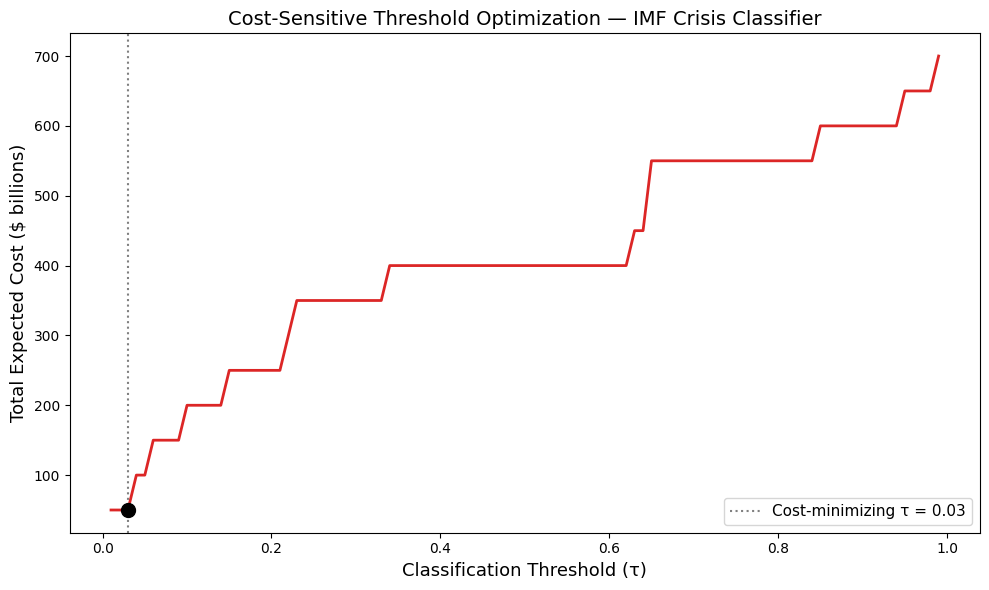

Cost-minimizing threshold: τ = 0.03
Total expected cost at τ = 0.03: $50.1 billion

For comparison:
  F1-optimal threshold:         τ = 0.13
  Capacity-constrained threshold: τ = 0.88


In [20]:
# ============================================================
# TASK 4.2: Cost-Sensitive Threshold Optimization
# ============================================================

# Cost assumptions (from the assignment):
# - A missed crisis (FN) costs ~$50 billion in contagion and emergency lending
# - A false alarm (FP) costs ~$2 million per unnecessary assessment mission
COST_FN = 50_000_000_000  # $50B per missed crisis
COST_FP = 2_000_000       # $2M per false alarm

threshold_range = np.arange(0.01, 1.00, 0.01)
costs = []

# Sweep thresholds: lowering the threshold flags more countries as "crisis,"
# which reduces FN (fewer missed crises) but increases FP (more false alarms).
# Cost-sensitive optimization finds the threshold where the total dollar cost
# of errors is minimized — this can differ sharply from the F1-optimal threshold
# because F1 treats FP and FN symmetrically, while the real-world costs are
# extremely asymmetric ($50B vs. $2M).
for tau in threshold_range:
    # The threshold converts continuous probabilities into binary decisions:
    # if P(crisis) >= tau, predict crisis; otherwise, predict no crisis.
    y_pred_tau = (y_prob_crisis >= tau).astype(int)
    cm = confusion_matrix(y_test_crisis, y_pred_tau)
    tn, fp, fn, tp = cm.ravel()

    # FN is weighted 25,000x more heavily than FP because a sovereign default
    # triggered by a missed crisis dwarfs the cost of a wasted assessment mission.
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

# Find cost-minimizing threshold
costs = np.array(costs)
min_idx = np.argmin(costs)
min_tau = threshold_range[min_idx]
min_cost = costs[min_idx]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, costs / 1e9, color='#dc2626', linewidth=2)

# Annotate cost-minimizing threshold
ax.axvline(x=min_tau, color='gray', linestyle=':', linewidth=1.5,
           label=f'Cost-minimizing τ = {min_tau:.2f}')
ax.plot(min_tau, min_cost / 1e9, 'ko', markersize=10)

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Total Expected Cost ($ billions)', fontsize=13)
ax.set_title('Cost-Sensitive Threshold Optimization — IMF Crisis Classifier', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Cost-minimizing threshold: τ = {min_tau:.2f}")
print(f"Total expected cost at τ = {min_tau:.2f}: ${min_cost/1e9:.1f} billion")
print(f"\nFor comparison:")
print(f"  F1-optimal threshold:         τ = {best_tau:.2f}")
print(f"  Capacity-constrained threshold: τ = {cap_tau:.2f}")

The cost-minimizing threshold (τ = 0.03) is far lower than both the F1-optimal threshold (τ = 0.13) and the capacity-constrained threshold (τ = 0.88) because it directly reflects the extreme asymmetry in error costs: at 50B per missed crisis versus $2M per false alarm, it is economically rational to flag nearly every country to avoid missing even a single sovereign default. The three thresholds differ because each optimizes a different objective: F1 balances precision and recall equally, the capacity constraint limits missions to 5, and cost minimization reflects the actual dollar consequences of each type of error. If the IMF can expand its mission capacity, the cost-minimizing threshold would be the economically rational choice, as the savings from catching additional crises far outweigh the marginal cost of additional assessment missions.